# 06 - Model Training & Testing
This notebook trains the data using multiple models and then evaluates each models performance on test data, along with assessing the impact of removing features

### Imports & Data Load

In [1]:
import pandas as pd
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, 
                             classification_report)
from sklearn.model_selection import StratifiedKFold, cross_val_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
X_train = pd.read_csv('../Data/processed/X_train.csv')
X_test = pd.read_csv('../Data/processed/X_test.csv')
y_train = pd.read_csv('../Data/processed/y_train.csv').squeeze()
y_test = pd.read_csv('../Data/processed/y_test.csv').squeeze()

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)

Train shape: (544, 24)
Test shape: (136, 24)


### Comparison of Different Models

In [3]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest':       RandomForestClassifier(random_state=42, n_estimators=100),
    'Naive Bayes':         GaussianNB(),
    'SVM':                 SVC(random_state=42, probability=True),
    'XGBoost':             XGBClassifier(random_state=42, eval_metric='logloss')
}

In [4]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    results.append({
        'Model': name,
        'Accuracy':  round(accuracy_score(y_test, y_pred) * 100, 2),
        'Precision': round(precision_score(y_test, y_pred) * 100, 2),
        'Recall':    round(recall_score(y_test, y_pred) * 100, 2),
        'F1 Score':  round(f1_score(y_test, y_pred) * 100, 2),
        'AUC-ROC':   round(roc_auc_score(y_test, y_prob) * 100, 2)
    })
    
results_df = pd.DataFrame(results).set_index('Model')
results_df

,Accuracy,Precision,Recall,F1 Score,AUC-ROC
Model,,,,,
Logistic Regression,91.91,89.86,93.94,91.85,97.51
Random Forest,85.29,85.94,83.33,84.62,93.55
Naive Bayes,83.82,86.67,78.79,82.54,92.21
SVM,91.18,92.19,89.39,90.77,97.92
XGBoost,86.76,87.50,84.85,86.15,95.74


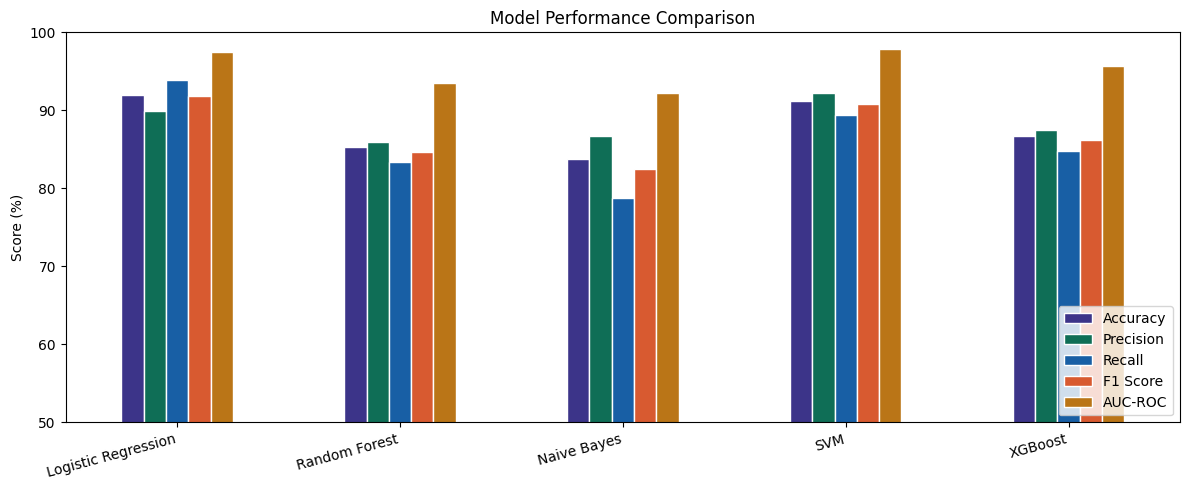

In [5]:

COLORS = ['#3C3489', '#0F6E56', '#185FA5', '#D85A30', '#BA7517']

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC-ROC']

results_df[metrics].plot(kind='bar', figsize=(12, 5), 
                          color=COLORS, edgecolor='white')
plt.title('Model Performance Comparison')
plt.ylabel('Score (%)')
plt.xlabel('')
plt.xticks(rotation=15, ha='right')
plt.legend(loc='lower right')
plt.ylim(50, 100)
plt.tight_layout()
plt.show()

### Confusion Matrix

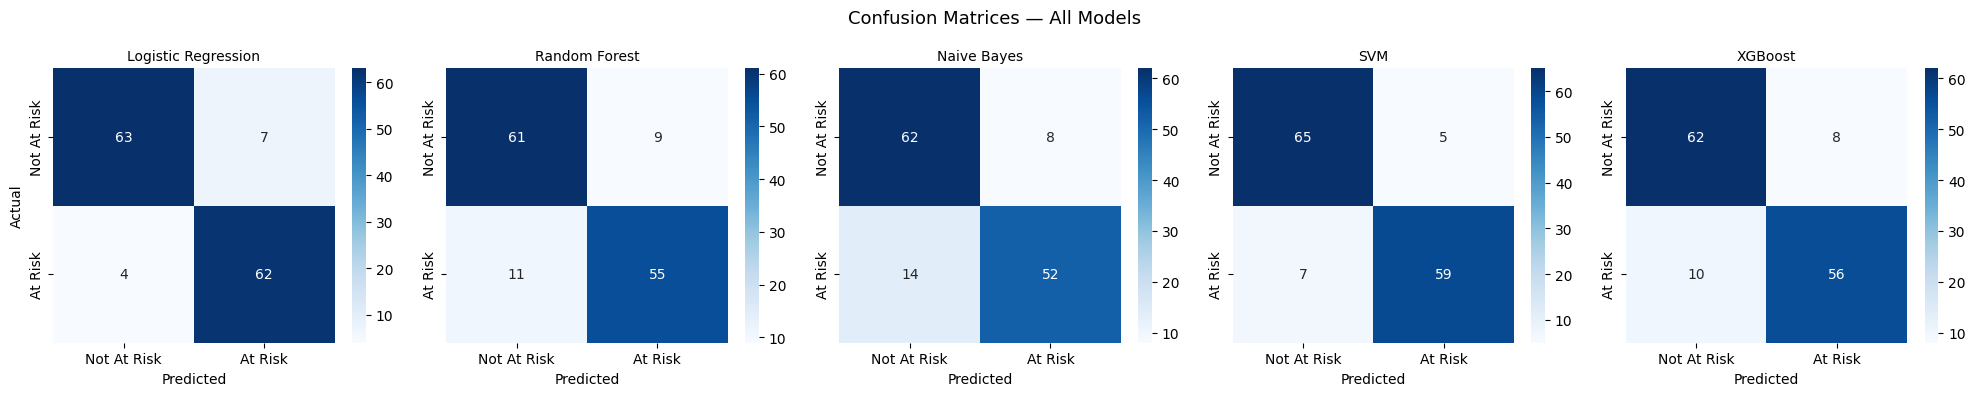

In [6]:
fig, axes = plt.subplots(1, len(models), figsize=(20, 4))

for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Not At Risk', 'At Risk'],
                yticklabels=['Not At Risk', 'At Risk'],
                ax=axes[i])
    axes[i].set_title(name, fontsize=10)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual' if i == 0 else '')

plt.suptitle('Confusion Matrices — All Models', fontsize=13)
plt.tight_layout()
plt.show()

### K-Fold Cross Validation

In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, 
                             cv=cv, scoring='f1')
    cv_results.append({
        'Model': name,
        'CV Mean F1': round(scores.mean() * 100, 2),
        'CV Std':     round(scores.std() * 100, 2)
    })

cv_df = pd.DataFrame(cv_results).set_index('Model')
cv_df

,CV Mean F1,CV Std
Model,,
Logistic Regression,86.76,3.83
Random Forest,82.05,3.77
Naive Bayes,77.92,1.86
SVM,84.11,2.76
XGBoost,83.75,1.47


In [8]:
best_model_name = results_df['F1 Score'].idxmax()
best_model = models[best_model_name]

print(f'Best Model: {best_model_name}')
print(f'\nClassification Report:')
print(classification_report(y_test, best_model.predict(X_test), 
                            target_names=['Not At Risk', 'At Risk']))

Best Model: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

 Not At Risk       0.94      0.90      0.92        70
     At Risk       0.90      0.94      0.92        66

    accuracy                           0.92       136
   macro avg       0.92      0.92      0.92       136
weighted avg       0.92      0.92      0.92       136



### Feature Importance

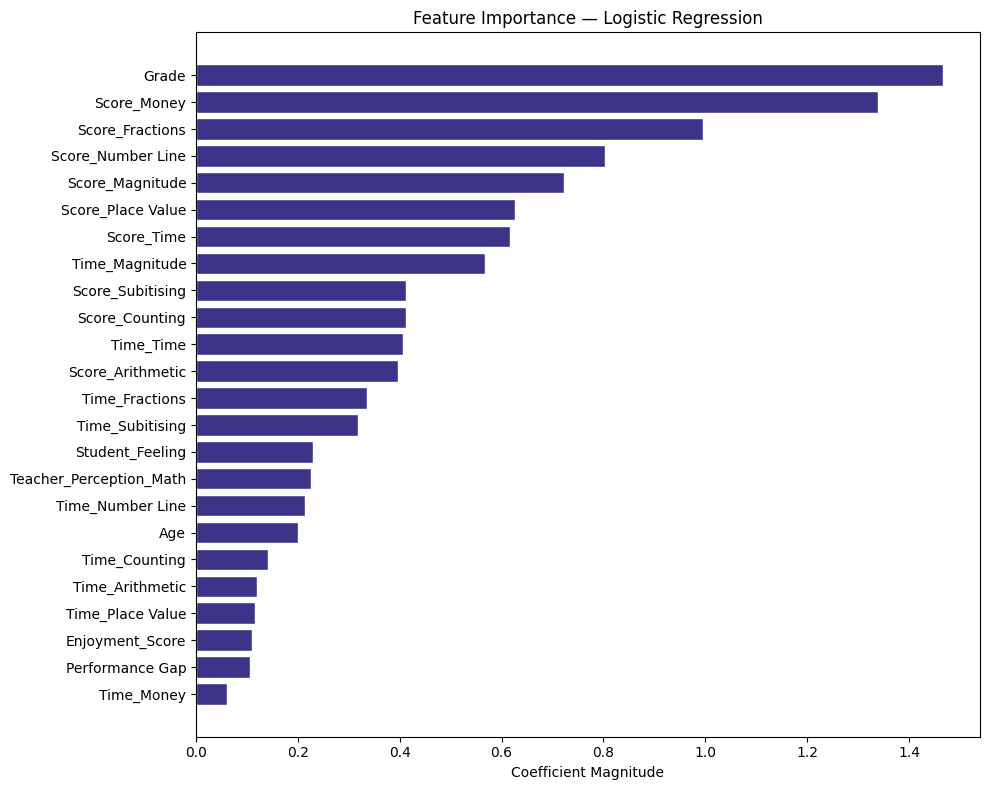

In [9]:
if hasattr(best_model, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=True)

    plt.figure(figsize=(10, 8))
    plt.barh(importance_df['Feature'], importance_df['Importance'],
             color=COLORS[0], edgecolor='white')
    plt.title(f'Feature Importance — {best_model_name}')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()

elif hasattr(best_model, 'coef_'):
    importance_df = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': abs(best_model.coef_[0])
    }).sort_values('Importance', ascending=True)

    plt.figure(figsize=(10, 8))
    plt.barh(importance_df['Feature'], importance_df['Importance'],
             color=COLORS[0], edgecolor='white')
    plt.title(f'Feature Importance — {best_model_name}')
    plt.xlabel('Coefficient Magnitude')
    plt.tight_layout()
    plt.show()

### Ablation Study

In [10]:
ablation_models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'SVM': SVC(random_state=42, probability=True)
}

feature_sets = {
    'Math Scores Only': [col for col in X_train.columns 
                         if col.startswith('Score_')],
    
    'Math Scores + Time': [col for col in X_train.columns 
                            if col.startswith('Score_') 
                            or col.startswith('Time_')],
    
    'Math Scores + Demographics': [col for col in X_train.columns 
                                    if col.startswith('Score_') 
                                    or col in ['Age', 'Grade']],
    
    
    'Math Scores + Academic': [col for col in X_train.columns 
                                if col.startswith('Score_') 
                                or col in ['Performance Gap',
                                           'Teacher_Perception_Math']],

    'Math Scores + Student Feedback': [col for col in X_train.columns 
                                        if col.startswith('Score_') 
                                        or col in ['Student_Feeling', 
                                                   'Enjoyment_Score']],
    
    'Without Time': [col for col in X_train.columns 
                     if not col.startswith('Time_')],
    
    
    'Without Academic': [col for col in X_train.columns 
                         if col not in ['Performance Gap',
                                        'Teacher_Perception_Math']],

    'Full Feature Set': list(X_train.columns)

}

ablation_results = []

for set_name, features in feature_sets.items():

    for model_name, model in ablation_models.items():

        model.fit(X_train[features], y_train)
        y_pred = model.predict(X_test[features])
        y_prob = model.predict_proba(X_test[features])[:, 1]
        
        ablation_results.append({
            'Feature Set': set_name,
            'Model Name': model_name,
            'Num Features': len(features),
            'Accuracy':  round(accuracy_score(y_test, y_pred) * 100, 2),
            'Precision': round(precision_score(y_test, y_pred) * 100, 2),
            'Recall':    round(recall_score(y_test, y_pred) * 100, 2),
            'F1 Score':  round(f1_score(y_test, y_pred) * 100, 2),
            'AUC-ROC':   round(roc_auc_score(y_test, y_prob) * 100, 2)
        })

ablation_df = pd.DataFrame(ablation_results)

ablation_df.head(20)

,Feature Set,Model Name,Num Features,Accuracy,Precision,Recall,F1 Score,AUC-ROC
0,Math Scores Only,Logistic Regression,9,80.15,84.21,72.73,78.05,89.92
1,Math Scores Only,SVM,9,80.88,81.25,78.79,80.00,89.12
2,Math Scores + Time,Logistic Regression,18,84.56,83.58,84.85,84.21,92.73
3,Math Scores + Time,SVM,18,84.56,85.71,81.82,83.72,92.67
4,Math Scores + Demographics,Logistic Regression,11,89.71,93.33,84.85,88.89,95.30
5,Math Scores + Demographics,SVM,11,89.71,91.94,86.36,89.06,96.08
6,Math Scores + Academic,Logistic Regression,11,82.35,87.50,74.24,80.33,90.44
7,Math Scores + Academic,SVM,11,82.35,82.81,80.30,81.54,90.10
8,Math Scores + Student Feedback,Logistic Regression,11,82.35,86.21,75.76,80.65,90.34
9,Math Scores + Student Feedback,SVM,11,83.09,82.09,83.33,82.71,89.66


### Saving Best Model

In [11]:
with open('../model/model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
